In [21]:
!uv pip install -qqq google-genai==1.67.0

In [22]:
import os
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from dotenv import load_dotenv
from google.genai import Client, types
from IPython.display import Audio, display
from pdf2image import convert_from_bytes

load_dotenv()

EMBEDDING_MODEL = "gemini-embedding-2-preview"

client = Client(api_key=os.environ["GEMINI_API_KEY"])

In [23]:
EXTENSION_TO_MIME_TYPE = defaultdict(
    lambda: "text/plain",
    {
        ".png": "image/png",
        ".jpg": "image/jpeg",
        ".jpeg": "image/jpeg",
        ".pdf": "application/pdf",
        ".mp3": "audio/mpeg",
    },
)

In [24]:
def embed_file(path: Path) -> np.ndarray[float]:
    data = path.read_bytes()

    result = client.models.embed_content(
        model=EMBEDDING_MODEL,
        contents=[
            types.Part.from_bytes(
                data=data, mime_type=EXTENSION_TO_MIME_TYPE[path.suffix]
            )
        ],
        config=types.EmbedContentConfig(task_type="RETRIEVAL_DOCUMENT"),
    )
    return np.array(result.embeddings[0].values)

In [25]:
def embed_query(query: str) -> np.ndarray[float]:
    result = client.models.embed_content(
        model=EMBEDDING_MODEL,
        contents=[query],
        config=types.EmbedContentConfig(task_type="RETRIEVAL_QUERY"),
    )
    return np.array(result.embeddings[0].values)

In [26]:
def cosine_sim(a: np.ndarray[float], b: np.ndarray[float]) -> float:
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

## Images


In [27]:
%%time

llama_embedding = embed_file(Path("assets/llama.png"))

CPU times: user 5.47 ms, sys: 3.02 ms, total: 8.48 ms
Wall time: 1.25 s


In [28]:
llama_embedding.shape

(3072,)

In [ ]:
%%time

penguin_embedding = embed_file(Path("assets/penguin.jpg"))

CPU times: user 4.49 ms, sys: 1.96 ms, total: 6.45 ms
Wall time: 1.24 s


In [30]:
cosine_sim(llama_embedding, penguin_embedding)

np.float64(0.7370555578484808)

## Embedding Query


In [31]:
%%time

query_embedding = embed_query("Which one is the penguin?")

CPU times: user 3.54 ms, sys: 1.24 ms, total: 4.78 ms
Wall time: 461 ms


In [32]:
print(cosine_sim(query_embedding, llama_embedding))
print(cosine_sim(query_embedding, penguin_embedding))

0.2924441552221528
0.36949116805306326


## PDF


In [33]:
%%time

llama_paper_embedding = embed_file(Path("assets/llama-paper-preview.pdf"))

CPU times: user 5.46 ms, sys: 2.29 ms, total: 7.75 ms
Wall time: 3.06 s


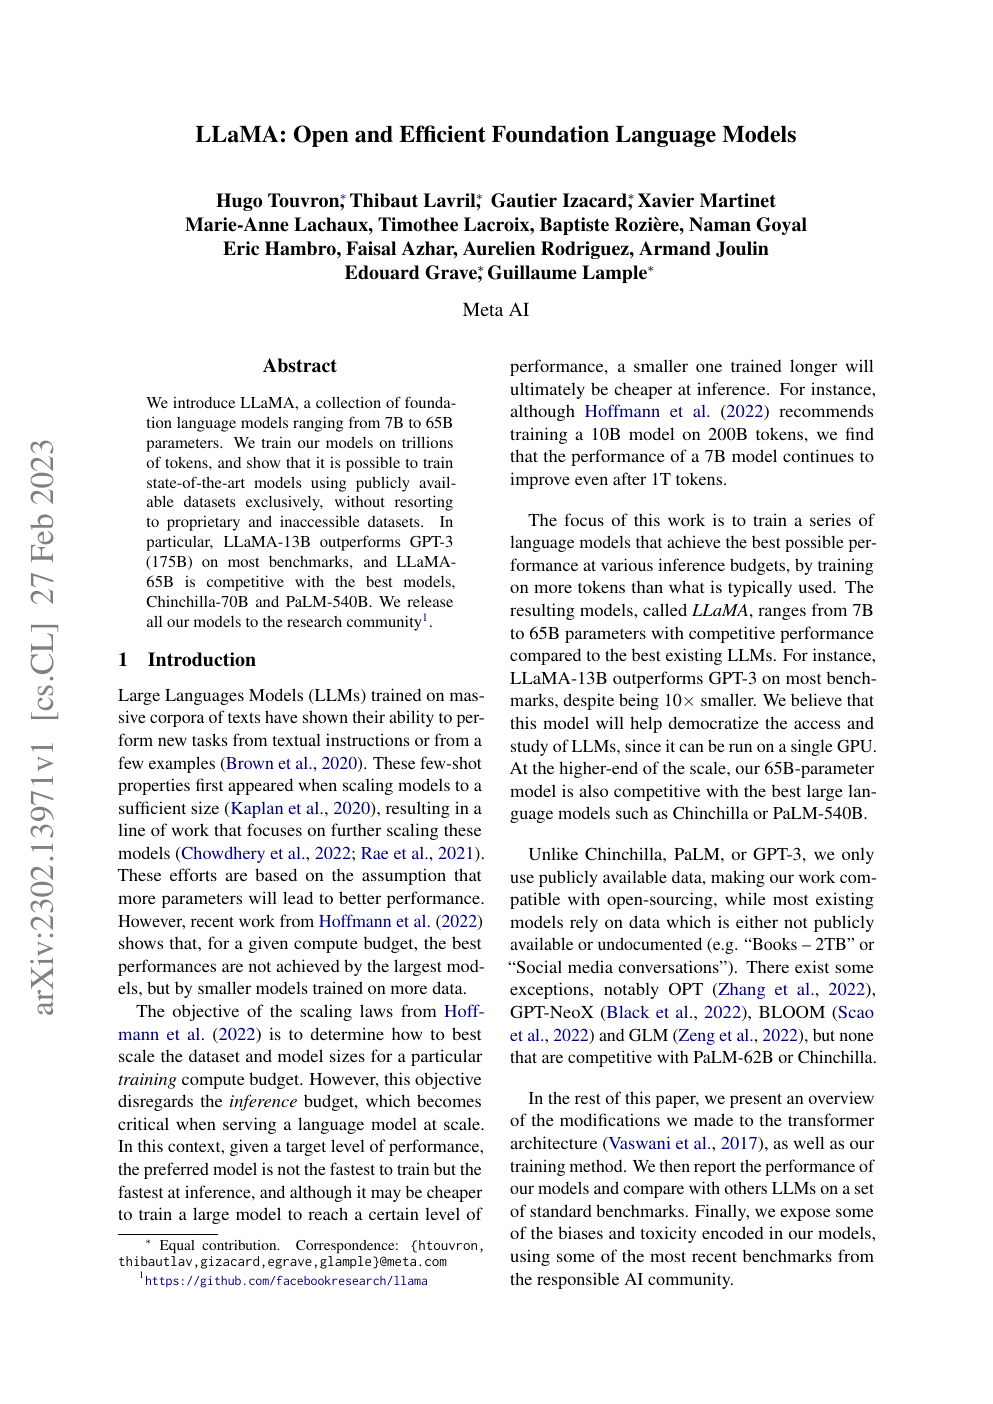

In [34]:
images = convert_from_bytes(
    Path("assets/llama-paper-preview.pdf").read_bytes(),
    first_page=1,
    last_page=1,
    dpi=120,
)
display(images[0])

## Audio


In [40]:
display(Audio(filename="assets/winamp-llama.mp3"))

In [41]:
%%time

winamp_llama_embedding = embed_file(Path("assets/winamp-llama.mp3"))

CPU times: user 5.53 ms, sys: 3.1 ms, total: 8.62 ms
Wall time: 890 ms


## Embedding Visualization


In [37]:
%%time

query_embedding = embed_query("I have a fondness for Llamas")

CPU times: user 4.08 ms, sys: 1.29 ms, total: 5.37 ms
Wall time: 414 ms


In [38]:
PRIMARY = "#4A7BF7"
SURFACE = "#FCFCFD"
TEXT = "#0F172A"
MUTED = "#526077"
GRID = "#E7EBF1"
RING = "#D6DCE5"


def _prepare_embeddings(
    query_embedding: np.ndarray,
    component_embeddings: dict[str, np.ndarray],
) -> tuple[list[str], dict[str, np.ndarray]]:
    if not isinstance(query_embedding, np.ndarray) or query_embedding.ndim != 1:
        raise ValueError("`query_embedding` must be a 1D numpy array.")
    if not component_embeddings:
        raise ValueError("`component_embeddings` must contain at least one embedding.")

    prepared = {"query": query_embedding}

    for label, embedding in component_embeddings.items():
        if not isinstance(embedding, np.ndarray) or embedding.ndim != 1:
            raise ValueError(f"Embedding for `{label}` must be a 1D numpy array.")
        if embedding.shape != query_embedding.shape:
            raise ValueError(
                f"Embedding for `{label}` has shape {embedding.shape}, expected {query_embedding.shape}."
            )
        prepared[label] = embedding

    return ["query", *component_embeddings.keys()], prepared


def _pca_2d(matrix: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    centered = matrix - matrix.mean(axis=0, keepdims=True)
    _, singular_values, vh = np.linalg.svd(centered, full_matrices=False)
    coords = centered @ vh[:2].T

    if coords.shape[1] == 1:
        coords = np.column_stack([coords[:, 0], np.zeros(len(coords))])

    variance = (singular_values**2) / max(len(matrix) - 1, 1)
    explained = variance[:2] / variance.sum() if variance.sum() else np.zeros(2)
    if explained.shape[0] == 1:
        explained = np.array([explained[0], 0.0])

    return coords, explained


def _scale(values: np.ndarray, low: float, high: float) -> np.ndarray:
    if len(values) == 0:
        return values
    if np.allclose(values.max(), values.min()):
        return np.full(values.shape, (low + high) / 2, dtype=float)
    return low + (values - values.min()) * (high - low) / (values.max() - values.min())


def plot_embedding_projection(
    query_embedding: np.ndarray,
    component_embeddings: dict[str, np.ndarray],
    query_label: str = "Query",
) -> None:
    labels, embeddings = _prepare_embeddings(query_embedding, component_embeddings)
    matrix = np.vstack([embeddings[label] for label in labels])
    coords, explained = _pca_2d(matrix)

    similarities = np.array(
        [
            1.0
            if label == "query"
            else cosine_sim(embeddings["query"], embeddings[label])
            for label in labels
        ]
    )
    corpus_sizes = _scale(similarities[1:], 260, 430)

    plt.style.use("seaborn-v0_8-whitegrid")
    fig, ax = plt.subplots(figsize=(10.5, 6.5), dpi=150)
    fig.patch.set_facecolor(SURFACE)
    ax.set_facecolor(SURFACE)

    query_x, query_y = coords[0]

    for idx in range(1, len(labels)):
        ax.plot(
            [query_x, coords[idx, 0]],
            [query_y, coords[idx, 1]],
            color=PRIMARY,
            linewidth=1.5,
            alpha=float(np.clip(0.18 + similarities[idx] * 0.45, 0.2, 0.55)),
            zorder=1,
        )

    scatter = None
    if len(labels) > 1:
        scatter = ax.scatter(
            coords[1:, 0],
            coords[1:, 1],
            s=corpus_sizes,
            c=similarities[1:],
            cmap="Blues",
            vmin=0.0,
            vmax=1.0,
            edgecolors=RING,
            linewidth=1.2,
            alpha=0.95,
            zorder=3,
        )

    ax.scatter(
        query_x,
        query_y,
        s=620,
        marker="*",
        c=PRIMARY,
        edgecolors=TEXT,
        linewidth=1.4,
        zorder=5,
    )

    x_offset = 0.035 * (np.ptp(coords[:, 0]) or 1.0)
    y_offset = 0.05 * (np.ptp(coords[:, 1]) or 1.0)

    for idx, label in enumerate(labels):
        title = query_label if label == "query" else label.replace("_", " ").title()
        detail = "" if label == "query" else f"\n {similarities[idx]:.3f}"
        ax.text(
            coords[idx, 0] + x_offset,
            coords[idx, 1] + y_offset,
            f"{title}{detail}",
            fontsize=11 if label == "query" else 10,
            fontweight="bold" if label == "query" else "medium",
            color=TEXT,
            bbox={
                "boxstyle": "round,pad=0.35,rounding_size=0.2",
                "facecolor": "white",
                "edgecolor": "none",
                "alpha": 0.94,
            },
            zorder=6,
        )

    ax.set_title(
        "Query vs Embeddings (PCA)",
        fontsize=18,
        fontweight="bold",
        color=TEXT,
        pad=20,
    )

    ax.set_xlabel(
        f"PC1 · {explained[0] * 100:.1f}% variance", fontsize=10.5, color=MUTED
    )
    ax.set_ylabel(
        f"PC2 · {explained[1] * 100:.1f}% variance", fontsize=10.5, color=MUTED
    )

    ax.grid(color=GRID, linewidth=0.9)
    ax.tick_params(colors=MUTED)

    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    ax.spines["left"].set_color(RING)
    ax.spines["bottom"].set_color(RING)
    ax.margins(0.2)

    if scatter is not None:
        cbar = fig.colorbar(scatter, ax=ax, pad=0.02, shrink=0.82)
        cbar.outline.set_visible(False)
        cbar.set_label("query cosine similarity", color=MUTED, fontsize=10)
        cbar.ax.tick_params(colors=MUTED)

    plt.show()

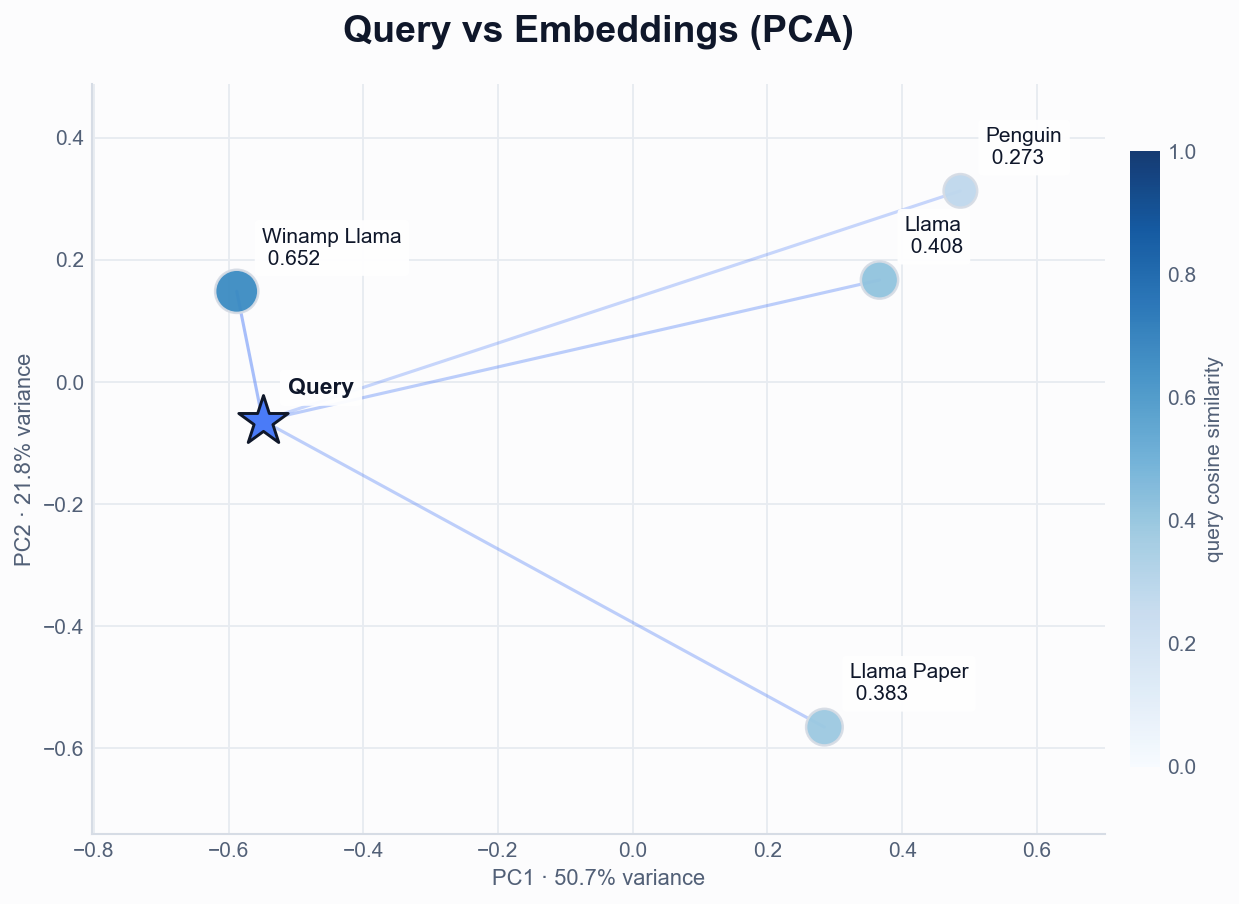

In [39]:
component_embeddings = {
    "llama": llama_embedding,
    "penguin": penguin_embedding,
    "winamp llama": winamp_llama_embedding,
    "llama paper": llama_paper_embedding,
}

plot_embedding_projection(
    query_embedding=query_embedding,
    component_embeddings=component_embeddings,
)

## References

- [Gemini Embeddings 2 Post](https://blog.google/innovation-and-ai/models-and-research/gemini-models/gemini-embedding-2/)
- [Gemini Embeddings NB](https://github.com/google-gemini/cookbook/blob/main/quickstarts/Embeddings.ipynb)
